# Telco Customer Churn — Modeling & Evaluation

**Author:** Allison Schiltz\

**Objectives**:
- Build two models to predict `Churn`:
    - For both models: **Class weights** will be used adjust for imbalanced data and **regularization** will be used to prevent overfitting.
    - **Logistic Regression** with regularizataion as a baseline and for interpretability. A baseline model helps determine whether a more complex model adds value. 
    - **Gradient Boosted Trees** using LightGBM for higher predictive power
    - **Optuna** will be using for hyperparameter tuning and cross-validation
- **Strategy**: 
    - Use a train/test split strategy with cross-validation (CV) plus a final holdout set.
    - Perform cross-validation on the training data to tune hyperparameters.
    - Evaluate the final model on the untouched test set (holdout) for an unbiased performance estimate.
- Prioritize **recall ≥ 0.70** and **ROC-AUC > 0.75**
    - **Recall** to identify as many customers at risk of churning as possible (minimizing false negatives). This is important in churn scenarios, where missing a potential churner can be costly for the business.
    - **ROC-AUC** to measure the model’s overall discriminative power to distinguish between churners and non-churners across all thresholds.

## 0. Environment & Imports

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import recall_score, roc_auc_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict


from optuna.integration import LightGBMTuner
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

In [2]:
import sys
print(sys.executable)

/Users/Allison/Code/.venv/bin/python


## 1. Load Data
- Load combined, preprocessed features and target labels needed for modeling.
- Load column-role manifest (ID, target, numeric, categorical, booleans)

In [3]:
# Load Training features
X_train_final = pd.read_csv('../data/processed/X_train_final.csv')
# Load Training target
y_train = pd.read_csv('../data/processed/y_train.csv')

# Load Test features
X_test_final = pd.read_csv('../data/processed/X_test_final.csv')
# Load Test target
y_test = pd.read_csv('../data/processed/y_test.csv')

# Load column role manifest
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

In [4]:
# Extract target column

y_train = y_train['Churn']
y_test = y_test['Churn']

In [5]:
print(X_train_final.shape)
print(y_train.shape, '\n')

print(X_test_final.shape)
print(y_test.shape)

(5625, 41)
(5625,) 

(1407, 41)
(1407,)


In [6]:
print(X_train_final.head())
print(X_test_final.head())
print(y_train.head())
print(y_test.head(), '\n')
print('X_train_final dtypes:', X_train_final.dtypes, '\n')
print('X_test_final dtypes:', X_test_final.dtypes, '\n')

   Unnamed: 0    tenure  MonthlyCharges  TotalCharges  total_services_eng  \
0        1408  1.321816        0.981556      1.659900            1.269948   
1        6992 -0.267410       -0.971546     -0.562252           -0.671868   
2        3349  1.444064        0.837066      1.756104            0.784494   
3        4486 -1.204646        0.641092     -0.908326           -0.186414   
4        3535  0.669826       -0.808787     -0.101561           -0.671868   

   gender_Male  SeniorCitizen_Yes  Partner_Yes  Dependents_Yes  \
0         True              False         True            True   
1         True              False        False           False   
2        False              False         True           False   
3         True              False        False           False   
4        False              False         True           False   

   PhoneService_Yes  ...  PaymentMethod_Mailed check  tenure_group_eng_13-24  \
0              True  ...                       False        

In [7]:
# Clean feature names for LightGBM compatibility
import re

def clean_feature_names(df):
    clean_cols = [re.sub(r'[\[\]{}:,"\s]', '_', str(col)) for col in df.columns]
    df.columns = clean_cols
    return df

X_train_final = clean_feature_names(X_train_final)
X_test_final = clean_feature_names(X_test_final)
print("Cleaned feature names for LightGBM.")

Cleaned feature names for LightGBM.


## 2. Baselines
1. Majority-class baseline:
- Predict the most frequent class for all cases (e.g., always predict "No Churn").
- Calculate and record metrics: recall, precision, ROC-AUC, PR-AUC. This sets a minimum performance bar.
2. Logistic regression baseline (with regularization):
- Train a logistic regression model using default or simple regularization (e.g., L2 penalty, class_weight="balanced").
- Evaluate on the validation or test set.
- Record the same metrics: recall, precision, ROC-AUC, PR-AUC.


In [8]:
# Majority class baseline
from sklearn.dummy import DummyClassifier

# Instantiate and fit dummy classifier
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_final, y_train.values.ravel())

# Predict class labels and class probabilities
y_pred_dummy = dummy.predict(X_test_final)
y_proba_dummy = dummy.predict_proba(X_test_final)[:, 1]

# Calculate and print metrics
print("Recall:", recall_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dummy))

Recall: 0.0
Precision: 0.0
ROC-AUC: 0.5


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [9]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
grid = GridSearchCV(logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
grid.fit(X_train_final, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg = grid.best_estimator_



In [10]:
print(best_logreg)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


In [11]:
# Evaluate the best Logistic Regression model using the best parameters
print("Best parameters:", grid.best_params_)
print("Mean cross-validated recall:", grid.best_score_)

cv_precision = cross_val_score(best_logreg, X_train_final, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", cv_precision.mean())
cv_roc_auc = cross_val_score(best_logreg, X_train_final, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", cv_roc_auc.mean())

Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8020066889632107
Mean cross-validated precision: 0.5261803314796728
Mean cross-validated ROC-AUC: 0.8479297415922324


## 4. Advanced Models
- Tree-based gradient boosting with LightGBM
- Hyperparameter tuning (Oputuna) with cross-validation
- Early stopping / model selection criteria

In [12]:
# LightGBM Model with Optuna Hyperparameter Tuning and Cross-Validation

import optuna.integration.lightgbm as lgb_optuna
import lightgbm as lgb

# Prepare data for LightGBM (no need for label column in features)
X = X_train_final
y = y_train

# Set up Optuna LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]


# Run Optuna hyperparameter tuning with cross-validation
optuna_lgbm = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm.run()


[I 2026-01-20 08:33:33,789] A new study created in memory with name: no-name-c5a660ab-2173-4d78-a031-8a62e2c8b183
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844429:  14%|#4        | 1/7 [00:01<00:08,  1.34s/it]

Early stopping, best iteration is:
[25]	valid's auc: 0.844429 + 0.00469507
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.845929:  29%|##8       | 2/7 [00:03<00:09,  1.85s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.845929 + 0.00456528
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  43%|####2     | 3/7 [00:04<00:05,  1.49s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.847109 + 0.00614192
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  57%|#####7    | 4/7 [00:05<00:03,  1.31s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.846445 + 0.00599438
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  71%|#######1  | 5/7 [00:06<00:02,  1.29s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84766 + 0.00508612
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  86%|########5 | 6/7 [00:07<00:01,  1.19s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.844421 + 0.00433494
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660: 100%|##########| 7/7 [00:09<00:00,  1.30s/it]


Early stopping, best iteration is:
[36]	valid's auc: 0.844399 + 0.00396617


num_leaves, val_score: 0.847660:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849527:   5%|5         | 1/20 [00:00<00:14,  1.35it/s]

Early stopping, best iteration is:
[24]	valid's auc: 0.849527 + 0.00433322
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849527:  10%|#         | 2/20 [00:04<00:47,  2.66s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.849527:  15%|#5        | 3/20 [00:08<00:55,  3.27s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850064:  20%|##        | 4/20 [00:09<00:35,  2.22s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850139:  25%|##5       | 5/20 [00:09<00:24,  1.63s/it]

Early stopping, best iteration is:
[53]	valid's auc: 0.850139 + 0.0040319
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850139:  30%|###       | 6/20 [00:10<00:17,  1.25s/it]

Early stopping, best iteration is:
[47]	valid's auc: 0.849861 + 0.003552
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850139:  35%|###5      | 7/20 [00:11<00:16,  1.28s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.844037 + 0.00513852
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850139:  40%|####      | 8/20 [00:13<00:18,  1.57s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842757 + 0.00450066
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  45%|####5     | 9/20 [00:14<00:14,  1.36s/it]

Early stopping, best iteration is:
[290]	valid's auc: 0.8507 + 0.00435556
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  50%|#####     | 10/20 [00:16<00:13,  1.36s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.845317 + 0.00497013
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  55%|#####5    | 11/20 [00:19<00:16,  1.85s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842615 + 0.00448559
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  60%|######    | 12/20 [00:22<00:19,  2.40s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84224 + 0.00486563
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  65%|######5   | 13/20 [00:23<00:13,  1.96s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.847619 + 0.00514597
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  70%|#######   | 14/20 [00:25<00:11,  1.91s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.842878 + 0.00562737
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  75%|#######5  | 15/20 [00:26<00:07,  1.49s/it]

Early stopping, best iteration is:
[89]	valid's auc: 0.849958 + 0.00433803
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  80%|########  | 16/20 [00:27<00:05,  1.33s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.847851 + 0.00483749
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  85%|########5 | 17/20 [00:28<00:04,  1.41s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.848364 + 0.00419741
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  90%|######### | 18/20 [00:29<00:02,  1.15s/it]

Early stopping, best iteration is:
[65]	valid's auc: 0.849643 + 0.00479063
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  95%|#########5| 19/20 [00:30<00:01,  1.31s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.845402 + 0.00480966
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700: 100%|##########| 20/20 [00:31<00:00,  1.59s/it]


Early stopping, best iteration is:
[18]	valid's auc: 0.84753 + 0.00538815


bagging, val_score: 0.850700:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851189:  10%|#         | 1/10 [00:00<00:08,  1.03it/s]

Early stopping, best iteration is:
[276]	valid's auc: 0.851189 + 0.00416298
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851207:  20%|##        | 2/10 [00:01<00:07,  1.08it/s]

Early stopping, best iteration is:
[276]	valid's auc: 0.851207 + 0.00406787
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851207:  30%|###       | 3/10 [00:02<00:05,  1.17it/s]

Early stopping, best iteration is:
[228]	valid's auc: 0.85103 + 0.00444276
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851207:  40%|####      | 4/10 [00:03<00:04,  1.28it/s]

Early stopping, best iteration is:
[189]	valid's auc: 0.850958 + 0.00420823
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851207:  50%|#####     | 5/10 [00:04<00:03,  1.29it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.85105 + 0.00430633
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851243:  60%|######    | 6/10 [00:04<00:03,  1.23it/s]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851243:  70%|#######   | 7/10 [00:05<00:02,  1.16it/s]

Early stopping, best iteration is:
[275]	valid's auc: 0.851146 + 0.00432787
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851243:  80%|########  | 8/10 [00:06<00:01,  1.12it/s]

Early stopping, best iteration is:
[188]	valid's auc: 0.850843 + 0.00441966
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851243:  90%|######### | 9/10 [00:08<00:01,  1.09s/it]

Early stopping, best iteration is:
[228]	valid's auc: 0.850341 + 0.00469743
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851243: 100%|##########| 10/10 [00:09<00:00,  1.06it/s]


Early stopping, best iteration is:
[168]	valid's auc: 0.849885 + 0.00476369


feature_fraction_stage2, val_score: 0.851243:   0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851243:  33%|###3      | 1/3 [00:01<00:02,  1.23s/it]

Early stopping, best iteration is:
[228]	valid's auc: 0.850864 + 0.00423069
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851243:  67%|######6   | 2/3 [00:02<00:01,  1.25s/it]

Early stopping, best iteration is:
[228]	valid's auc: 0.851076 + 0.0043912
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851243: 100%|##########| 3/3 [00:03<00:00,  1.10s/it]


Early stopping, best iteration is:
[231]	valid's auc: 0.85112 + 0.00443592


regularization_factors, val_score: 0.851243:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:   5%|5         | 1/20 [00:01<00:21,  1.14s/it]

Early stopping, best iteration is:
[228]	valid's auc: 0.851379 + 0.00413381
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  10%|#         | 2/20 [00:02<00:19,  1.08s/it]

Early stopping, best iteration is:
[336]	valid's auc: 0.851174 + 0.00449542
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  15%|#5        | 3/20 [00:03<00:19,  1.14s/it]

Early stopping, best iteration is:
[337]	valid's auc: 0.850783 + 0.00464339
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  20%|##        | 4/20 [00:04<00:17,  1.12s/it]

Early stopping, best iteration is:
[342]	valid's auc: 0.85114 + 0.00445872
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  25%|##5       | 5/20 [00:05<00:15,  1.04s/it]

Early stopping, best iteration is:
[275]	valid's auc: 0.85123 + 0.00395262
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  30%|###       | 6/20 [00:06<00:13,  1.01it/s]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  35%|###5      | 7/20 [00:07<00:13,  1.02s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  40%|####      | 8/20 [00:08<00:13,  1.17s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  45%|####5     | 9/20 [00:09<00:12,  1.12s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  50%|#####     | 10/20 [00:10<00:10,  1.07s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  55%|#####5    | 11/20 [00:11<00:09,  1.04s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  60%|######    | 12/20 [00:12<00:08,  1.03s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  65%|######5   | 13/20 [00:13<00:07,  1.04s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  70%|#######   | 14/20 [00:14<00:06,  1.02s/it]

Early stopping, best iteration is:
[275]	valid's auc: 0.85123 + 0.00395021
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  75%|#######5  | 15/20 [00:16<00:05,  1.08s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393725
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  80%|########  | 16/20 [00:16<00:04,  1.03s/it]

Early stopping, best iteration is:
[276]	valid's auc: 0.851243 + 0.00393968
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  85%|########5 | 17/20 [00:17<00:02,  1.00it/s]

Early stopping, best iteration is:
[280]	valid's auc: 0.851369 + 0.00411691
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  90%|######### | 18/20 [00:18<00:02,  1.01s/it]

Early stopping, best iteration is:
[279]	valid's auc: 0.851337 + 0.00415925
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379:  95%|#########5| 19/20 [00:19<00:00,  1.04it/s]

Early stopping, best iteration is:
[228]	valid's auc: 0.851262 + 0.00416063
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851379: 100%|##########| 20/20 [00:20<00:00,  1.04s/it]


Early stopping, best iteration is:
[231]	valid's auc: 0.851343 + 0.00426042


min_child_samples, val_score: 0.851379:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851404:  20%|##        | 1/5 [00:00<00:03,  1.09it/s]

Early stopping, best iteration is:
[228]	valid's auc: 0.851404 + 0.00410862
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851404:  40%|####      | 2/5 [00:01<00:02,  1.13it/s]

Early stopping, best iteration is:
[228]	valid's auc: 0.85112 + 0.00422539
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851413:  60%|######    | 3/5 [00:02<00:01,  1.10it/s]

Early stopping, best iteration is:
[228]	valid's auc: 0.851413 + 0.00418121
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851413:  80%|########  | 4/5 [00:03<00:00,  1.00it/s]

Early stopping, best iteration is:
[228]	valid's auc: 0.851413 + 0.00418121
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851413: 100%|##########| 5/5 [00:04<00:00,  1.06it/s]

Early stopping, best iteration is:
[233]	valid's auc: 0.851347 + 0.00425858


In [13]:
# Get best parameters and best score for LightGBM
print('Best params:', optuna_lgbm.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm = lgb.LGBMClassifier(**optuna_lgbm.best_params, random_state=SEED)
cv_recall = cross_val_score(best_lgbm, X_train_final, y_train, cv=5, scoring='recall')
cv_precision = cross_val_score(best_lgbm, X_train_final, y_train, cv=5, scoring='precision')
cv_roc_auc = cross_val_score(best_lgbm, X_train_final, y_train, cv=5, scoring='roc_auc')
print('Mean cross-validated recall:', cv_recall.mean())
print('Mean cross-validated precision:', cv_precision.mean())
print('Mean cross-validated ROC-AUC:', cv_roc_auc.mean())

Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.9135346768614057, 'lambda_l2': 0.07116790985328339, 'num_leaves': 2, 'feature_fraction': 0.4, 'bagging_fraction': 0.6450989926248821, 'bagging_freq': 6, 'min_child_samples': 5}
Mean cross-validated recall: 0.8220735785953177
Mean cross-validated precision: 0.5081221050423013
Mean cross-validated ROC-AUC: 0.8450440127300849


## 5. Evaluation
- Test and select optimal probability thresholds
- Compare model performance on the validation set, prioritizing recall
- Plot ROC and Precision–Recall curves to visualize trade-offs
- Display confusion matrices at selected thresholds
- Tune thresholds to achieve recall ≥ 0.70, while monitoring precision

### Current metrics
**Logistic Regression Model:**
- Mean cross-validated recall: 0.8020066889632107
- Mean cross-validated precision: 0.5259734519943968
- Mean cross-validated ROC-AUC: 0.8479451278272208

**LightGBM Model:**
- Mean cross-validated recall: 0.8127090301003344
- Mean cross-validated precision: 0.5094201411980942
- Mean cross-validated ROC-AUC: 0.846322284936876

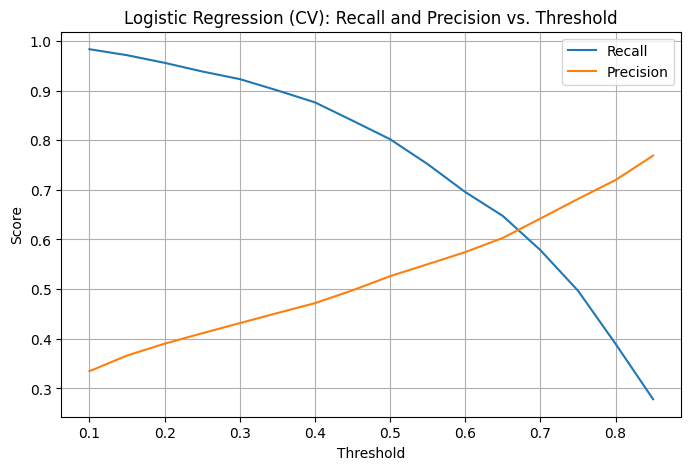

Threshold: 0.50, Recall: 0.80, Precision: 0.53
Threshold: 0.55, Recall: 0.75, Precision: 0.55


In [14]:
# Test probability thresholds for Logistic Regression Model

# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba = cross_val_predict(best_logreg, X_train_final, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    y_pred = (cv_pred_proba >= thresh).astype(int)
    recalls.append(recall_score(y_train, y_pred))
    precisions.append(precision_score(y_train, y_pred))

# Plot recall and precision vs. threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression (CV): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and prec >= 0.50
for thresh, rec, prec in zip(thresholds, recalls, precisions):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

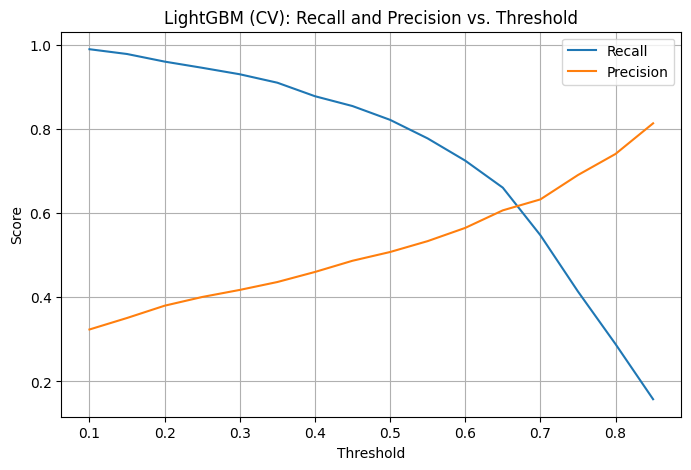

Threshold: 0.50, Recall: 0.82, Precision: 0.51
Threshold: 0.55, Recall: 0.78, Precision: 0.53
Threshold: 0.60, Recall: 0.73, Precision: 0.57


In [15]:
# Test probability thresholds for LightGBM model using cross-validated predictions

# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_lgbm = cross_val_predict(best_lgbm, X_train_final, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_lgbm >= thresh).astype(int)
    recalls.append(recall_score(y_train, y_pred))
    precisions.append(precision_score(y_train, y_pred))

# Plot recall and precision vs. threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('LightGBM (CV): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and prec >= 0.50
for thresh, rec, prec in zip(thresholds, recalls, precisions):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

In [16]:
# Calculate confusion matrices for 0.5 threshold on training data for both models
# Logistic Regression
best_logreg.fit(X_train_final, y_train)
y_proba_logreg_train = best_logreg.predict_proba(X_train_final)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train = confusion_matrix(y_train, y_pred_logreg_train)
print("Confusion Matrix - Logistic Regression (0.5 threshold, training data):\n", cm_logreg_train)

# LightGBM
best_lgbm.fit(X_train_final, y_train)
y_proba_lgbm_train = best_lgbm.predict_proba(X_train_final)[:, 1]
y_pred_lgbm_train = (y_proba_lgbm_train >= 0.5).astype(int)
cm_lgbm_train = confusion_matrix(y_train, y_pred_lgbm_train)
print("Confusion Matrix - LightGBM (0.5 threshold, training data):\n", cm_lgbm_train)

Confusion Matrix - Logistic Regression (0.5 threshold, training data):
 [[3052 1078]
 [ 282 1213]]
Confusion Matrix - LightGBM (0.5 threshold, training data):
 [[2930 1200]
 [ 249 1246]]


In [17]:
# Display confusion matrices as percentages (row-wise)
import pandas as pd

def confusion_matrix_percentages(cm):
    cm = cm.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    percent_cm = np.round(100 * cm / row_sums, 2)
    return percent_cm

# Logistic Regression
cm_logreg_train_pct = confusion_matrix_percentages(cm_logreg_train)
print("Confusion Matrix - Logistic Regression (0.5 threshold, training data, %):\n", cm_logreg_train_pct)

# LightGBM
cm_lgbm_train_pct = confusion_matrix_percentages(cm_lgbm_train)
print("Confusion Matrix - LightGBM (0.5 threshold, training data, %):\n", cm_lgbm_train_pct)

Confusion Matrix - Logistic Regression (0.5 threshold, training data, %):
 [[73.9  26.1 ]
 [18.86 81.14]]
Confusion Matrix - LightGBM (0.5 threshold, training data, %):
 [[70.94 29.06]
 [16.66 83.34]]


### Comparison of Confusion Matrices
#### Confusion Matrix - Logistic Regression (0.5 threshold)

|                | % Predicted: No (0) | % Predicted: Yes (1) |
|----------------|-------------------|--------------------|
| % Actual: No (0) | 73.9            |26.1              |
| % Actual: Yes (1)| 18.86           |81.14                |

#### Confusion Matrix - LightGBM (0.5 threshold)

|                | Predicted: No (0) | Predicted: Yes (1) |
|----------------|-------------------|--------------------|
| Actual: No (0) | 70.94             |29.06                |
| Actual: Yes (1)| 17.19             |82.81                |

Both models have similar performance. LightGBM has slightly fewer false negatives (17% vs. 19%) and more true positives (83% vs. 81%), but also more false positives (29% vs. 26%) and fewer true negatives (71% vs. 74%).

### Comparison of thresholds with recall >= 0.7 and precision >= 0.5

|Threshold| Logistic Regression Model       | LightGBM Model                |
|----------|--------------------------------|-------------------------------|
|0.50       |Recall: 0.80, Precision: 0.53  |Recall: 0.81, Precision: 0.51  |
|0.55       |Recall: 0.75, Precision: 0.55  |Recall: 0.78, Precision: 0.54  |
|0.60       |N/A                            |Recall: 0.73, Precision: 0.57  |

For both models, a threshold of 0.5 maximizes recall and keeps precision > 0.5 

**Comparison and Rationale:**

Businesses typically aim to identify at least 70% of actual churners (recall ≥ 0.7) and prefer that at least half of the customers flagged as churners actually do churn (precision ≥ 0.5). Both the Logistic Regression and LightGBM models meet these criteria, though both have higher recall than precision at each threshold. As expected, lowering the threshold increases recall but decreases precision. At the 0.50 threshold, Logistic Regression achieves a slightly lower recall (0.80 vs. 0.81) but a marginally higher precision (0.53 vs. 0.51) compared to LightGBM. Overall, the models perform similarly, with only minor differences in these key metrics.

**Final Model Choice:**

Based on this evaluation, the Logistic Regression model was selected as the final model for two main reasons:

1. It achieves recall above 0.7 and precision above 0.5, aligning with the business goal of identifying as many potential churners as possible while maintaining reasonable precision.
2. Logistic Regression is simpler and more interpretable than LightGBM, making it easier to explain and deploy.

Note: In practice, the optimal model choice may depend on additional business factors, such as the relative costs of customer churn versus retention offers, which are not specified here.

## 6. Final Model Selection & Test Set Results
- Retrain final model on entire training dataset using best hyperparameters and preprocessing
- Evaluate on untouched test set
- Report final metrics (recall, precision, ROC-AUC)


In [18]:
# Retrain Logistic Regression on full training data with best hyperparameters
# Best params were C=0.1, class_weight='balanced', max_iter=1000, solver='liblinear'

final_logreg = LogisticRegression(
    C=best_logreg.C,
    penalty=best_logreg.penalty,
    solver=best_logreg.solver,
    class_weight=best_logreg.class_weight,
    max_iter=1000,
    random_state=SEED
)

final_logreg.fit(X_train_final, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
# Predict on test set
y_pred_final_logreg = final_logreg.predict(X_test_final)
y_proba_final_logreg = final_logreg.predict_proba(X_test_final)[:, 1]

In [20]:
y_pred_final_logreg_thresh = (y_proba_final_logreg >= 0.5).astype(int)

In [21]:

# Evaluate final logistic regression model on test set

from sklearn.metrics import recall_score, precision_score, roc_auc_score, confusion_matrix

# Compare predictions to true labels
recall = recall_score(y_test, y_pred_final_logreg_thresh)
precision = precision_score(y_test, y_pred_final_logreg_thresh)
roc_auc = roc_auc_score(y_test, y_proba_final_logreg)
cm = confusion_matrix(y_test, y_pred_final_logreg_thresh)

print(f"Recall: {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print("Confusion Matrix:")
print(cm)



Recall: 0.789
Precision: 0.494
ROC-AUC: 0.837
Confusion Matrix:
[[731 302]
 [ 79 295]]


In [22]:
# Display percent confusion matrix for final logistic regression model (test set)
def confusion_matrix_percentages(cm):
    cm = cm.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    percent_cm = np.round(100 * cm / row_sums, 2)
    return percent_cm

cm_pct = confusion_matrix_percentages(cm)
print("Confusion Matrix (% of actual class, row-normalized) - Final Logistic Regression (0.5 threshold, test set, %):\n", cm_pct)


Confusion Matrix (% of actual class, row-normalized) - Final Logistic Regression (0.5 threshold, test set, %):
 [[70.76 29.24]
 [21.12 78.88]]


In [26]:
# Determine most important predictors for final logistic regression model

# Get feature names and coefficients
feature_names = X_train_final.columns
coefs = final_logreg.coef_.flatten()

# Create DataFrame of features and coefficients
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
})

# Sort by absolute value of coefficient (importance)
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

# Display top 15 predictors
print(coef_df.head(15))

                                 feature  coefficient  abs_coefficient
27                     Contract_Two_year    -0.855423         0.855423
1                                 tenure    -0.623566         0.623566
38             is_month_to_month_eng_Yes     0.609766         0.609766
9                       PhoneService_Yes    -0.548145         0.548145
35                 tenure_group_eng_7-12    -0.535424         0.535424
39  short_tenure_month_to_month_eng_True     0.526483         0.526483
12           InternetService_Fiber_optic     0.490030         0.490030
15                    OnlineSecurity_Yes    -0.458432         0.458432
21                       TechSupport_Yes    -0.427557         0.427557
30        PaymentMethod_Electronic_check     0.349643         0.349643
2                         MonthlyCharges     0.344322         0.344322
33                tenure_group_eng_25-48    -0.298623         0.298623
32                tenure_group_eng_13-24    -0.285256         0.285256
17    

In [28]:
# Load the column manifest with readable labels
manifest = pd.read_csv('../references/telco_column_role_manifest_with_labels.csv')

# Create a mapping: feature code → readable label
# Adjust column names as needed based on your manifest structure
feature_map = dict(zip(manifest['column_name'], manifest['readable_label']))

# Map features in coef_df to readable labels
coef_df['readable_label'] = coef_df['feature'].map(feature_map).fillna(coef_df['feature'])

# Display top predictors with readable labels
print(coef_df[['readable_label', 'coefficient', 'abs_coefficient']].head(10))

                          readable_label  coefficient  abs_coefficient
27                     Contract_Two_year    -0.855423         0.855423
1                        Tenure (months)    -0.623566         0.623566
38                  Month-to-Month (Yes)     0.609766         0.609766
9                          Phone Service    -0.548145         0.548145
35            Tenure Group (7-12 months)    -0.535424         0.535424
39  Short Tenure & Month-to-Month (True)     0.526483         0.526483
12        Internet Service (Fiber Optic)     0.490030         0.490030
15                 Online Security (Yes)    -0.458432         0.458432
21                    Tech Support (Yes)    -0.427557         0.427557
30        PaymentMethod_Electronic_check     0.349643         0.349643


/var/folders/xk/1_94y7fn37sf7kbch2g77hlm0000gp/T/ipykernel_48533/4129743794.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')


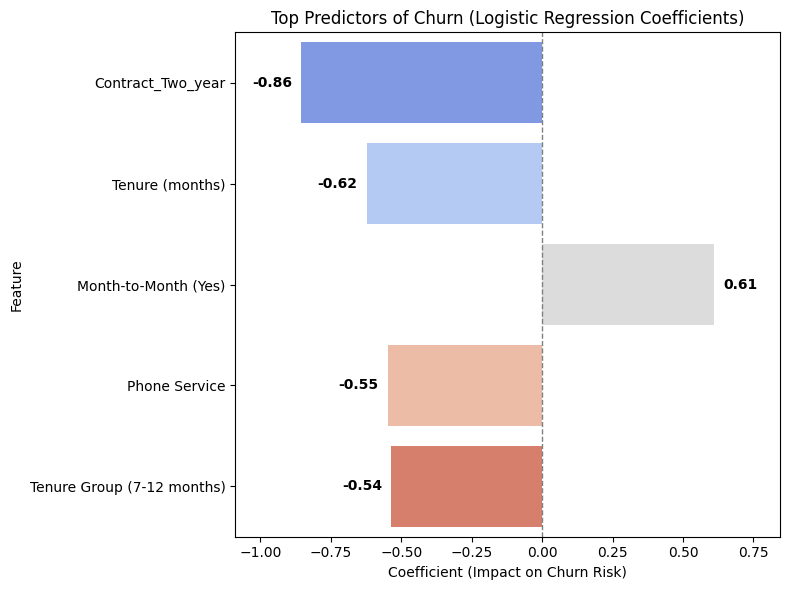

In [49]:
# Plot top predictors for churn from logistic regression model

top_n = 5
top_coef = coef_df.head(top_n).copy()
plt.figure(figsize=(8, 6))  # Wide figure for more space
ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')
plt.title('Top Predictors of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Churn Risk)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Set x-limits to add more space for annotation text
xlim = ax.get_xlim()
x_pad = 0.1 * (xlim[1] - xlim[0])
plt.xlim(xlim[0] - x_pad, xlim[1] + x_pad)

# Annotate each bar with its coefficient value, always outside the bar
for bar, coef in zip(ax.patches, top_coef['coefficient']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        text_x = x + 0.02 * (xlim[1] - xlim[0])
        ha = 'left'
    else:
        text_x = x - 0.02 * (xlim[1] - xlim[0])
        ha = 'right'
    ax.text(text_x, y, f'{coef:.2f}', va='center', ha=ha, color='black', fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()
plt.show()

### Comparison of Validation and Test Set Performance for Final Logistic Regression Model

The table below summarizes key metrics at the 0.50 probability threshold, comparing the model’s performance on the validation set (cross-validated training data) to its performance on the holdout test set after retraining on the full training data. This allows for an assessment of model generalization and consistency across data splits.

**Note on terminology:**
- The "validation set" refers to the portion of the training data used during cross-validation to tune hyperparameters and select the best model. These results reflect model performance during development, before seeing the test set.
- The "test set" (also called the holdout set) is a separate, untouched dataset set aside at the start of the project. It is only used for the final evaluation after all model selection and tuning are complete, providing an unbiased estimate of real-world performance.


| Metric             | Validation Set | Test Set |
|--------------------|----------------|----------|
|Recall             | 0.80            | 0.79     |
|Precision          | 0.53            | 0.49     |
|ROC-AUC            | 0.845           | 0.837    |
|Confusion Matrix (% of actual class)   |                 |          |
|    - True Neg (TN)  | 73.9           | 70.76      |
|    - False Pos (FP) | 26.1           | 29.24      |
|    - False Neg (FN) | 18.86           | 21.12      |
|    - True Pos (TP)  | 81.14           | 78.88      |

**Summary**:
- The model generalizes well—there’s no sign of severe overfitting.
- The small drop in precision and recall is expected when moving from validation to test data.
- These differences are minor and within the range of normal variation.
